In [2]:
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import math

file = './data/measurement_l1a.nc'
dataset = nc.Dataset(file)

print(dataset.variables.keys())

dict_keys(['echo_sample_ind', 'sar_ku_pulse_burst_ind', 'sar_c_pulse_burst_ind', 'time_l1a_echo_sar_ku', 'UTC_day_l1a_echo_sar_ku', 'UTC_sec_l1a_echo_sar_ku', 'UTC_time_20hz_l1a_echo_sar_ku', 'isp_coarse_time_l1a_echo_sar_ku', 'isp_fine_time_l1a_echo_sar_ku', 'flag_time_status_l1a_echo_sar_ku', 'sral_fine_time_l1a_echo_sar_ku', 'lat_l1a_echo_sar_ku', 'lon_l1a_echo_sar_ku', 'surf_type_l1a_echo_sar_ku', 'burst_count_prod_l1a_echo_sar_ku', 'seq_count_l1a_echo_sar_ku', 'burst_count_cycle_l1a_echo_sar_ku', 'nav_bul_status_l1a_echo_sar_ku', 'nav_bul_source_l1a_echo_sar_ku', 'oper_instr_l1a_echo_sar_ku', 'SAR_mode_l1a_echo_sar_ku', 'cl_gain_l1a_echo_sar_ku', 'acq_stat_l1a_echo_sar_ku', 'dem_eeprom_l1a_echo_sar_ku', 'weighting_l1a_echo_sar_ku', 'loss_track_l1a_echo_sar_ku', 'h0_nav_dem_l1a_echo_sar_ku', 'h0_applied_l1a_echo_sar_ku', 'cor2_nav_dem_l1a_echo_sar_ku', 'cor2_applied_l1a_echo_sar_ku', 'dh0_l1a_echo_sar_ku', 'agccode_ku_l1a_echo_sar_ku', 'agccode_c_l1a_echo_sar_ku', 'alt_l1a_echo_sar

In [3]:
import folium

flight_path = []

lats = dataset.variables['lat_l1a_echo_sar_ku'][:]
lons = dataset.variables['lon_l1a_echo_sar_ku'][:]

lat_min, lat_max = 49.0, 55.0
lon_min, lon_max = 14.0, 24.5

poland_mask = (lats >= lat_min) & (lats <= lat_max) & (lons >= lon_min) & (lons <= lon_max)

poland_lats = lats[poland_mask]
poland_lons = lons[poland_mask]

for lat, lon in zip(poland_lats[::500], poland_lons[::500]):
    flight_path.append((lat, lon))

m = folium.Map(location=[52.0, 19.0], zoom_start=7, tiles="OpenStreetMap")
folium.PolyLine(flight_path, color="blue", weight=2.5, opacity=1).add_to(m)

display(m);

[4.47213595499958 8.602325267042627 12.041594578792296 6.4031242374328485
 7.211102550927979]
[ 2.67794504 -2.19104581 -2.41495031 -2.46685171  0.5880026 ]


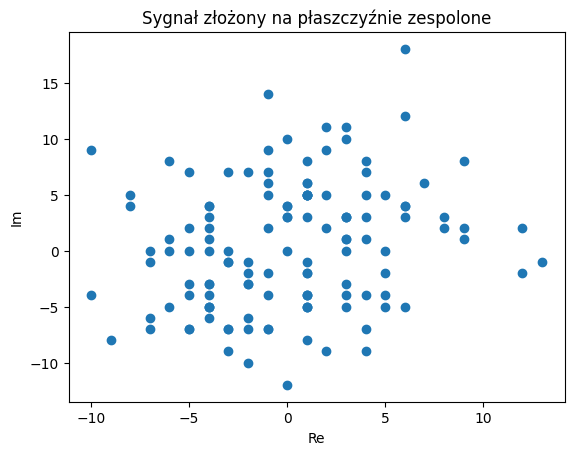

In [3]:
burst_idx = 0

I = dataset.variables['i_meas_ku_l1a_echo_sar_ku'][burst_idx, :, :]
Q = dataset.variables['q_meas_ku_l1a_echo_sar_ku'][burst_idx, :, :]

# Kodu nie ma wiele, ale teorii jest sporo, zapisuje jak to rozumiem.
# Mamy informacje o pomiarach I oraz Q, które są składowymi sygnału radarowego. I to chwilowa amplituda pomnozona przez cosinus a Q to chwilowa amplituda pomnozona przez sinus.
complex_signal = I + 1j * Q


plt.scatter(complex_signal[0].real, complex_signal[0].imag)
plt.xlabel("Re")
plt.ylabel("Im")
plt.title("Sygnał złożony na płaszczyźnie zespolone")

# To jest pojedynczy puls radaru, generalnie przy satelicie SAR używamy radaru impulsowego z modulacją częstotliwości, nie jest tak jak w przypadku radaru z kolokwium 1, gdzie wysyłaliśmy puls i czekaliśmy na odpowiedź. 
# Częstotliwość sygnału zmienia się w czasie, radar wysyła puls, milknie i czeka na echo. Potem dzięki znajomości oryginalnego sygnału mozemy obliczyć odległość od obiektu.
# Taki sygnał ze zmodulowaną częstotliwością (chirp) jest znacznie łatwiejszy do wykrycia wśród szumu i w przeciwieństwie do radaru z kolokwium 1 wymaga znacznie mniejszej mocy.

# Przejdę teraz do policzenia amplitudy i fazy w czasie dla przykładowego sygnału:
amplitudes_0 = np.abs(complex_signal[0])
angles_0 = np.angle(complex_signal[0])

print(amplitudes_0[:5])
print(angles_0[:5])

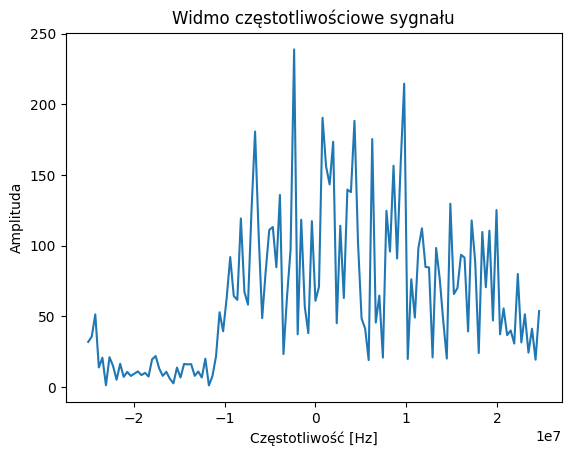

In [4]:
# Do oszacowania odległości potrzebujemy zastosować FFT, na satelicie zastosowano tzw. DERAMPING. Deramping polega na tym, że sygnał nadawany jest w postaci chirp, a następnie po odbiorze sygnału jest on mieszany z kopią sygnału nadawanego. W wyniku tego powstaje sygnał o stałej częstotliwości, którego częstotliwość jest proporcjonalna do odległości od obiektu. Następnie stosujemy FFT, aby uzyskać widmo częstotliwościowe, które pozwala nam określić odległość.

N = 128
frequencies = np.fft.fftfreq(N, d=1/50e6)
range_compressed = np.fft.fft(complex_signal, axis=-1)

frequencies_shifted = np.fft.fftshift(frequencies)
range_compressed_shifted = np.fft.fftshift(range_compressed, axes=-1)

plt.plot(frequencies_shifted, np.abs(range_compressed_shifted[0]))
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
plt.title("Widmo częstotliwościowe sygnału")
plt.show()

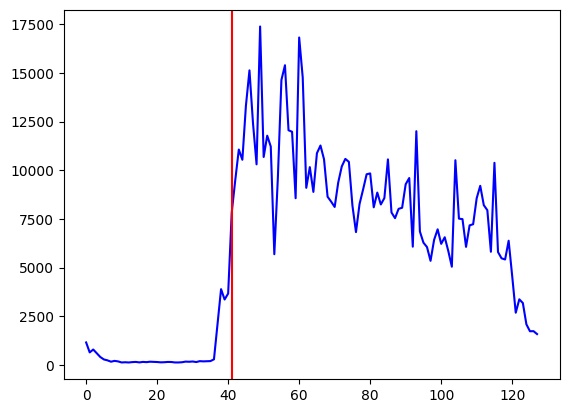

Wysokość nad ziemią: 2797.01 m


In [5]:
power_pulses = np.abs(range_compressed_shifted) ** 2
averaged_waveform = np.mean(power_pulses, axis=0)

reference_step = np.zeros(128)
reference_step[64:] = np.max(averaged_waveform)
cross_corr = np.correlate(averaged_waveform, reference_step, mode='same')

detected_gate = np.argmax(cross_corr)

c = 299792458
bandwidth = 350e6
gate_resolution = c / (2 * bandwidth)

R_coarse = dataset.variables['range_ku_l1a_echo_sar_ku'][burst_idx]
R_fine = (detected_gate - 64) * gate_resolution

R_total = R_coarse + R_fine

H_satellite = dataset.variables['alt_l1a_echo_sar_ku'][burst_idx]
surface_elevation = H_satellite - R_total

plt.plot(averaged_waveform, color='blue')
plt.axvline(x=detected_gate, color='red')
plt.show()

print(f"Wysokość nad ziemią: {surface_elevation:.2f} m")

In [6]:
def get_altitude(complex_signal, burst_idx):
    range_compressed = np.fft.fft(complex_signal, axis=-1)
    range_compressed_shifted = np.fft.fftshift(range_compressed, axes=-1)

    power_pulses = np.abs(range_compressed_shifted) ** 2
    averaged_waveform = np.mean(power_pulses, axis=0)

    reference_step = np.zeros(128)
    reference_step[64:] = np.max(averaged_waveform)
    cross_corr = np.correlate(averaged_waveform, reference_step, mode='same')

    detected_gate = np.argmax(cross_corr)

    c = 299792458
    bandwidth = 350e6
    gate_resolution = c / (2 * bandwidth)

    R_coarse = dataset.variables['range_ku_l1a_echo_sar_ku'][burst_idx]
    R_fine = (detected_gate - 64) * gate_resolution

    R_total = R_coarse + R_fine

    H_satellite = dataset.variables['alt_l1a_echo_sar_ku'][burst_idx]
    surface_elevation = H_satellite - R_total

    return surface_elevation

In [16]:
poland_indices = np.argwhere(poland_mask).flatten()

ids = np.array([])
poland_alts = np.array([])

for idx in poland_indices:
    I_idx = dataset.variables['i_meas_ku_l1a_echo_sar_ku'][idx, :, :]
    Q_idx = dataset.variables['q_meas_ku_l1a_echo_sar_ku'][idx, :, :]
    
    complex_signal_idx = I_idx + 1j * Q_idx

    elev = get_altitude(complex_signal_idx, idx)
    poland_alts = np.append(poland_alts, elev)
    ids = np.append(ids, idx)


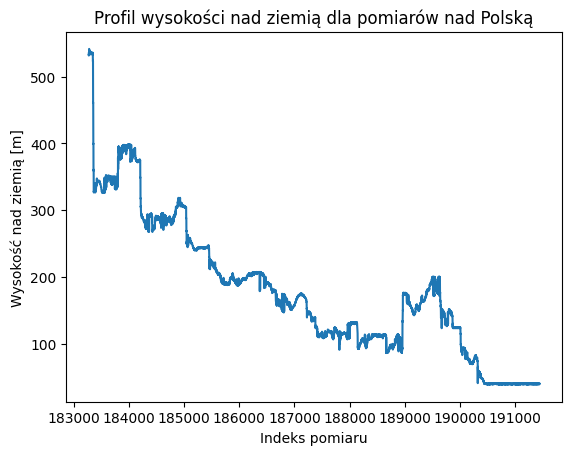

In [22]:
plt.plot(ids, poland_alts)
plt.xlabel("Indeks pomiaru")
plt.ylabel("Wysokość nad ziemią [m]")
plt.title("Profil wysokości nad ziemią dla pomiarów nad Polską")
plt.show()

In [32]:
# mozemy zwalidowac powyzszy wykres porownujac z danymi z jakiegos api, moze byc wyrywkowo albo jakas sensowna probka

lats = dataset.variables['lat_l1a_echo_sar_ku'][:]
lons = dataset.variables['lon_l1a_echo_sar_ku'][:]

poland_lats = lats[poland_mask]
poland_lons = lons[poland_mask]

coordinates = np.array([])

for lat, lon in zip(poland_lats[::500], poland_lons[::500]):
    coordinates = np.append(coordinates, (lat, lon))

print(coordinates.shape)
print(coordinates)

# np zweryfikowac te punkty i naniesc na wykres, tak zeby mniej wiecej sprawdzic rozbieznosci

# ewentualnie kolejna opcja to proba poprawy jakosci obliczen, na pewno jest to do zrobienia w jakis sposób

(34,)
[49.000211 18.482106 49.36879  18.323467 49.73719  18.162843 50.105408
 18.000176 50.47344  17.835409 50.841281 17.668484 51.208925 17.499337
 51.576369 17.327906 51.943606 17.154123 52.310632 16.977919 52.677441
 16.799224 53.044028 16.617962 53.410386 16.434057 53.77651  16.24743
 54.142392 16.057996 54.508026 15.865669 54.873406 15.67036 ]


In [ ]:
dataset.close()